# 0. Carga de datos


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Ventas

In [36]:
# Cargar datos
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas = pd.read_csv(path_ventas)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_93150/3745035006.py:3: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


Ventas - Filas: 10596574


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,HR,ZV01,2025-01-03,43790,NaN,55,HORECA VOLUMEN,MORTADELAS,...,SANTIAGO HORECA PAP,2715.0,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,HR,ZV01,2025-01-03,1227049,NaN,37,OTROS HORECA,VIENESAS,...,SANTIAGO HORECA PAP,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,NaN,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,HR,ZV01,2025-01-03,1015869,NaN,55,HORECA VOLUMEN,PARRILLEROS,...,SANTIAGO HORECA PAP,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista', 'dscto_base',
       'id_descuento_base', 'dscto_volumen', 'ids_descuento_volumen',
       'dscto_binario', 'id_descuento_binario', 'carta_impacto',
       'id_descuento_carta_impacto'],
      dtype='str')

In [40]:
dict(zip(ventas['Cod Consolidado'], ventas['Nombre Consolidado']))

{32: 'COBERTURA',
 55: 'HORECA VOLUMEN',
 37: 'OTROS HORECA',
 54: 'VOLUMEN COBERTURA',
 56: 'HR ACUERDOS COMERC.',
 57: 'MAYORISTA B VOLUMEN',
 70: 'HR CUENTAS CLAVES.',
 38: 'OTROS MAYORISTAS',
 67: 'MAYORISTAS CADENAS',
 65: 'CHILECOMPRA'}

In [4]:
print(ventas["Kilos Nc"].isna().sum())
ventas = ventas[ventas["Kilos Nc"].isna()]

9853682


In [5]:
# ventas["Nombre Consolidado"].unique()
## Filtrar solo los canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    # "MAYORISTAS CADENAS",
    # "MAYORISTA B VOLUMEN",
    # "OTROS MAYORISTAS",
    # "HORECA VOLUMEN",
    # "OTROS HORECA",
]
# ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
ventas = ventas[
    # ((ventas["Año"] == 2025) & (ventas["Mes"] >= 10)) |
    (ventas["Año"] == 2026)
]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 2158092


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
116,2026,2,HR,ZV01,2026-02-16,1227986,NaN,37,OTROS HORECA,SALAMES,...,SANTIAGO CENTRO COSTA,8274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,2026,2,HR,ZV01,2026-02-04,1176438,NaN,37,OTROS HORECA,MORTADELAS,...,ANTOFAGASTA,4008.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,2026,2,CB,ZV01,2026-02-16,1035323,NaN,54,VOLUMEN COBERTURA,SALAMES,...,SAN FELIPE,8274.0,-3.0,1249.0,NaN,NaN,NaN,NaN,NaN,NaN
119,2026,2,CB,ZV01,2026-02-16,1011205,NaN,32,COBERTURA,SALAMES,...,RANCAGUA,8274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,2026,2,CB,ZV01,2026-02-09,1035323,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,SAN FELIPE,3717.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ventas después de filtrar canales irrelevantes - Filas: 2158092


In [6]:
# Filtrar columnas relevantes
cols_relevantes_ventas = [
    # Id Cliente
    "Cod Cliente", 
    # Info Canal
    "Cod Canal Comercial", "Cod Consolidado", "Zona", "Distrito",
    # Fecha real de la venta
    "Fecha Factura",
    # Id Producto
    "Cod SKU",
    # Info Producto
    "Nombre SKU",
    # Monto Venta
    "Monto Real",
    # Cantidad Venta
    "Kilo Real",
    # Precio real (por kg)
    "Precio",
    # Precio Lista
    "Precio_Lista",
    # Descuentos
    "dscto_base", "dscto_volumen", "dscto_binario", "carta_impacto",
    "id_descuento_base", "ids_descuento_volumen", "id_descuento_binario", "id_descuento_carta_impacto"
    ]
ventas = ventas[cols_relevantes_ventas]
ventas.head()

,Cod Cliente,Cod Canal Comercial,Cod Consolidado,Zona,Distrito,Fecha Factura,Cod SKU,Nombre SKU,Monto Real,Kilo Real,Precio,Precio_Lista,dscto_base,dscto_volumen,dscto_binario,carta_impacto,id_descuento_base,ids_descuento_volumen,id_descuento_binario,id_descuento_carta_impacto
116,1227986,HR,37,SANTIAGO,SANTIAGO CENTRO COSTA,2026-02-16,3112,SALAME PIEZA 1KG LP,8274,1.0,8274.0,8274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,1176438,HR,37,NORTE 1,ANTOFAGASTA,2026-02-04,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",108216,27.0,4008.0,4008.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,7033.0,8274.0,-3.0,NaN,NaN,NaN,1249.0,NaN,NaN,NaN
119,1011205,CB,32,SUR 1,RANCAGUA,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,7033.0,8274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-09,8517,SALCHICHON CERVEZA MINI PZA 8x400 GR WI,22308,12.0,1859.0,3717.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Contar nans por columna
nans_por_columna = ventas.isna().sum()
print("Nans por columna:")
print(nans_por_columna)

Nans por columna:
Cod Cliente                         0
Cod Canal Comercial                 0
Cod Consolidado                     0
Zona                            13454
Distrito                        13454
Fecha Factura                       0
Cod SKU                             0
Nombre SKU                          0
Monto Real                          0
Kilo Real                           0
Precio                              0
Precio_Lista                      438
dscto_base                    1879129
dscto_volumen                 1400996
dscto_binario                 1583951
carta_impacto                 2158062
id_descuento_base             1879129
ids_descuento_volumen         1400996
id_descuento_binario          1583951
id_descuento_carta_impacto    2158062
dtype: int64


In [8]:
# Indicar cuantas filas y columnas tiene el dataframe antes de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas antes de filtrar.")

# Filtrar datos con nans en alguna columna relevante que no sea de descuentos
ventas = ventas.dropna(subset=[col for col in cols_relevantes_ventas if col not in ["Zona", "Distrito", "dscto_base", "dscto_volumen", "dscto_binario", "carta_impacto", "id_descuento_base", "ids_descuento_volumen", "id_descuento_binario", "id_descuento_carta_impacto"]])

# Indicar cuantas filas y columnas tiene el dataframe después de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas después de filtrar.")

El dataframe tiene 2158092 filas y 20 columnas antes de filtrar.
El dataframe tiene 2157654 filas y 20 columnas después de filtrar.


## 0.2. Maestro SKUs

In [9]:
# Cargar datos
path_maestro = "datos/Maestro Productos.xlsx"
maestro = pd.read_excel(path_maestro, header=2)
maestro.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [10]:
# Filtrar columnas relevantes
cols_relevantes_maestro = [
    # Id Producto
    "Material",
    # Info Producto
    "Texto breve de material",
    # Producto con peso cte?
    "Peso Var/Std",
    # Kg por Unidad
    "Neto"
]
maestro = maestro[cols_relevantes_maestro]
maestro["peso_variable"] = maestro["Peso Var/Std"] != "Peso Standard"
maestro.drop(columns="Peso Var/Std", inplace=True)
maestro.head()

,Material,Texto breve de material,Neto,peso_variable
0,20,ARROLLADO LOMO CON AJI SJ,3.172,True
1,21,ARROLLADO LOMO CORTADO SJ,2.000,False
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,0.250,False
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,0.250,False
4,27,ARROLLADO LOMO SIN AJI SJ,3.268,True


# 1. Cruces de bases y filtros preliminares


In [11]:
# Normalizar nombres de columnas y derivar año/mes desde Fecha Factura
ventas.columns = [
    "cod_cliente",
    "cod_canal_comercial", "cod_consolidado", "zona", "distrito",
    "fecha_factura",
    "cod_sku",
    "nombre_sku",
    "monto_real",
    "kilo_real",
    "precio_real",
    "precio_lista",
    "dscto_base", "dscto_volumen", "dscto_binario", "carta_impacto",
    "id_descuento_base", "ids_descuento_volumen", "id_descuento_binario", "id_descuento_carta_impacto"
]
ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"], errors="coerce")
ventas = ventas.dropna(subset=["fecha_factura"]).copy()
ventas["año_factura"] = ventas["fecha_factura"].dt.year.astype(int)
ventas["mes_factura"] = ventas["fecha_factura"].dt.month.astype(int)

maestro.columns = [
    "cod_sku",
    "texto_breve_material",
    "kg_por_unidad",
    "peso_variable"
]
# Agregar columna de kg_por_unidad a ventas
ventas = ventas.merge(maestro[["cod_sku", "kg_por_unidad", "peso_variable"]], on="cod_sku", how="left")

# Calcular cantidad en unidades
ventas["cantidad_unidades"] = ventas["kilo_real"] / ventas["kg_por_unidad"]
ventas.head()
# Revisar que columnas con cantidad_unidades no entera sean las mismas que las que tienen peso_variable = True
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades"].isna() | np.isclose(ventas["cantidad_unidades"], np.round(ventas["cantidad_unidades"]), atol=1e-6, rtol=0)

ventas["peso_variable"] = ventas["peso_variable"].fillna(False)
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades_entera"].fillna(True)
ventas["inconsistencia"] = (ventas["peso_variable"] == False) & (ventas["cantidad_unidades_entera"] == False)

ventas["inconsistencia"].value_counts()
# Ver columnas con inconsistencia
ventas[ventas["inconsistencia"]].head()
# Decidir que hacer con estas filas
# -> Redondear unidades a entero, dejar registro en un columna unidades_redondeadas (Bool)
ventas["cantidad_unidades"] = np.where(ventas["inconsistencia"], np.round(ventas["cantidad_unidades"]), ventas["cantidad_unidades"])
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,ids_descuento_volumen,id_descuento_binario,id_descuento_carta_impacto,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
0,1227986,HR,37,SANTIAGO,SANTIAGO CENTRO COSTA,2026-02-16,3112,SALAME PIEZA 1KG LP,8274,1.0,...,NaN,NaN,NaN,2026,2,1.0,False,1.0,True,False
1,1176438,HR,37,NORTE 1,ANTOFAGASTA,2026-02-04,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",108216,27.0,...,NaN,NaN,NaN,2026,2,1.8,False,15.0,True,False
2,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,NaN,NaN,NaN,2026,2,1.0,False,1.0,True,False
3,1011205,CB,32,SUR 1,RANCAGUA,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,NaN,NaN,NaN,2026,2,1.0,False,1.0,True,False
4,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-09,8517,SALCHICHON CERVEZA MINI PZA 8x400 GR WI,22308,12.0,...,NaN,NaN,NaN,2026,2,0.4,False,30.0,True,False


# 2. Análisis


In [12]:
# Filtrar ventas para tener sólo de unidades mayores a 0
ventas = ventas[ventas["cantidad_unidades"] > 0]

In [13]:
# Calcular precio por unidad en cada venta
ventas["precio_por_unidad"] = ventas["monto_real"] / ventas["cantidad_unidades"]
ventas["precio_lista_por_unidad"] = ventas["precio_lista"] * ventas["kg_por_unidad"]

ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,id_descuento_carta_impacto,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad,precio_lista_por_unidad
0,1227986,HR,37,SANTIAGO,SANTIAGO CENTRO COSTA,2026-02-16,3112,SALAME PIEZA 1KG LP,8274,1.0,...,NaN,2026,2,1.0,False,1.0,True,False,8274.0,8274.0
1,1176438,HR,37,NORTE 1,ANTOFAGASTA,2026-02-04,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",108216,27.0,...,NaN,2026,2,1.8,False,15.0,True,False,7214.4,7214.4
2,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,NaN,2026,2,1.0,False,1.0,True,False,7033.0,8274.0
3,1011205,CB,32,SUR 1,RANCAGUA,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,NaN,2026,2,1.0,False,1.0,True,False,7033.0,8274.0
4,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-09,8517,SALCHICHON CERVEZA MINI PZA 8x400 GR WI,22308,12.0,...,NaN,2026,2,0.4,False,30.0,True,False,743.6,1486.8


In [14]:
# Agregar columna de descuento aplicado.
# Se considera que una venta calza con un descuento si el descuento porcentual observado
# queda dentro de una tolerancia chica respecto a uno de los descuentos disponibles.
# Prioridad global: carta_impacto -> base -> volumen_1 -> volumen_2 -> volumen_3 -> binario.
# Entre descuentos porcentuales se elige el de menor diferencia absoluta; ante empate,
# la comparación estricta diff < mejor_diff preserva el orden base -> volumen_1 -> volumen_2 -> volumen_3 -> binario.

tolerancia_pct = 1
eps_descuento = 1e-9
tolerancia_precio_carta = 1.0
labels_descuento = np.array([
    "ninguno",
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
], dtype=object)

# Descuento porcentual observado a nivel de precio por unidad.
descuento_pct_observado = ((ventas["precio_por_unidad"] / ventas["precio_lista_por_unidad"]) - 1.0).to_numpy(dtype=np.float32) * np.float32(100.0)

# Se guarda sólo el mejor match para no materializar matrices grandes en memoria.
mejor_diff = np.full(len(ventas), np.inf, dtype=np.float32)
codigos_descuento = np.zeros(len(ventas), dtype=np.int8)
descuento_pct_matcheado = np.zeros(len(ventas), dtype=np.float32)
id_descuento_aplicado = np.full(len(ventas), np.nan, dtype=np.float64)

def _actualizar_mejor_match(candidatos, codigo, ids_candidatos=None):
    candidatos = pd.to_numeric(candidatos, errors="coerce").to_numpy(dtype=np.float32)
    validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
    if not validos.any():
        return

    diff = np.abs(descuento_pct_observado - candidatos)
    mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff)
    mejor_diff[mask] = diff[mask]
    codigos_descuento[mask] = codigo
    descuento_pct_matcheado[mask] = candidatos[mask]
    if ids_candidatos is not None:
        ids_candidatos = pd.to_numeric(ids_candidatos, errors="coerce").to_numpy(dtype=np.float64)
        id_descuento_aplicado[mask] = ids_candidatos[mask]

_actualizar_mejor_match(ventas["dscto_base"], 1, ventas["id_descuento_base"])

# dscto_volumen viene serializado como string tipo "[-5.0, -10.0]" en el CSV final.
# ids_descuento_volumen viene serializado como string tipo "[12, 25]" y sigue el mismo orden.
mask_volumen = ventas["dscto_volumen"].notna() & ventas["ids_descuento_volumen"].notna()
if mask_volumen.any():
    volumen_extraido = ventas.loc[mask_volumen, "dscto_volumen"].astype("string").str.extract(
        r"\[\s*([-\d\.]+)?(?:,\s*([-\d\.]+))?(?:,\s*([-\d\.]+))?\s*\]"
    )
    ids_volumen_extraidos = ventas.loc[mask_volumen, "ids_descuento_volumen"].astype("string").str.extract(
        r"\[\s*([-\d\.]+)?(?:,\s*([-\d\.]+))?(?:,\s*([-\d\.]+))?\s*\]"
    )
    idx_volumen = np.flatnonzero(mask_volumen.to_numpy())

    for codigo, col in enumerate(volumen_extraido.columns, start=2):
        candidatos = pd.to_numeric(volumen_extraido[col], errors="coerce").to_numpy(dtype=np.float32)
        ids_candidatos = pd.to_numeric(ids_volumen_extraidos[col], errors="coerce").to_numpy(dtype=np.float64)
        validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
        if not validos.any():
            continue

        diff = np.abs(descuento_pct_observado[idx_volumen] - candidatos)
        mejor_diff_local = mejor_diff[idx_volumen]
        mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff_local)
        if mask.any():
            idx_target = idx_volumen[mask]
            mejor_diff[idx_target] = diff[mask]
            codigos_descuento[idx_target] = codigo
            descuento_pct_matcheado[idx_target] = candidatos[mask]
            id_descuento_aplicado[idx_target] = ids_candidatos[mask]

_actualizar_mejor_match(ventas["dscto_binario"], 5, ventas["id_descuento_binario"])

# carta_impacto representa un precio objetivo, no un descuento porcentual, y si calza por precio_real
# dentro de la tolerancia definida, pisa cualquier match porcentual previo.
precio_real_array = pd.to_numeric(ventas["precio_real"], errors="coerce").to_numpy(dtype=np.float32)
precio_lista_array = pd.to_numeric(ventas["precio_lista"], errors="coerce").to_numpy(dtype=np.float32)
carta_array = pd.to_numeric(ventas["carta_impacto"], errors="coerce").to_numpy(dtype=np.float32)
carta_ids_array = pd.to_numeric(ventas["id_descuento_carta_impacto"], errors="coerce").to_numpy(dtype=np.float64)
carta_pct_equivalente = np.where(
    (~np.isnan(carta_array)) & (~np.isnan(precio_lista_array)) & (np.abs(precio_lista_array) > eps_descuento),
    ((carta_array / precio_lista_array) - np.float32(1.0)) * np.float32(100.0),
    np.nan,
)
mask_carta = (~np.isnan(carta_array)) & (np.abs(precio_real_array - carta_array) <= tolerancia_precio_carta)
codigos_descuento[mask_carta] = 6
descuento_pct_matcheado[mask_carta] = carta_pct_equivalente[mask_carta]
mejor_diff[mask_carta] = np.abs(descuento_pct_observado[mask_carta] - descuento_pct_matcheado[mask_carta])
id_descuento_aplicado[mask_carta] = carta_ids_array[mask_carta]

ventas["descuento_pct_observado"] = descuento_pct_observado
ventas["descuento_pct_matcheado"] = descuento_pct_matcheado
ventas["diferencia_descuento_pct"] = ventas["descuento_pct_observado"] - ventas["descuento_pct_matcheado"]
ventas["descuento_aplicado"] = pd.Categorical.from_codes(codigos_descuento, categories=labels_descuento)
ventas["id_descuento_aplicado"] = pd.array(id_descuento_aplicado, dtype="Int64")
ventas["calza_con_descuento"] = np.not_equal(codigos_descuento, 0)

print("Distribución descuento_aplicado:")
print(ventas["descuento_aplicado"].value_counts(dropna=False))
print(f"Cobertura de match: {ventas['calza_con_descuento'].mean():.2%}")

cols_muestra = [
    "cod_sku",
    "cod_canal_comercial",
    "cod_consolidado",
    "fecha_factura",
    "precio_por_unidad",
    "precio_lista_por_unidad",
    "descuento_pct_observado",
    "dscto_base",
    "id_descuento_base",
    "dscto_volumen",
    "ids_descuento_volumen",
    "dscto_binario",
    "id_descuento_binario",
    "carta_impacto",
    "id_descuento_carta_impacto",
    "descuento_pct_matcheado",
    "diferencia_descuento_pct",
    "descuento_aplicado",
    "id_descuento_aplicado",
]
ventas.loc[ventas["calza_con_descuento"], cols_muestra].head()

Distribución descuento_aplicado:
descuento_aplicado
ninguno          1474250
binario           347050
base              149874
volumen_1         124774
volumen_2          38249
volumen_3          23421
carta_impacto         28
Name: count, dtype: int64
Cobertura de match: 31.67%


,cod_sku,cod_canal_comercial,cod_consolidado,fecha_factura,precio_por_unidad,precio_lista_por_unidad,descuento_pct_observado,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado
6,8512,CB,54,2026-02-03,6132.00,7214.4,-15.003326,-3.0,3405.0,NaN,NaN,-15.0,4837.0,NaN,NaN,-15.0,-0.003326,binario,4837
8,3112,HR,55,2026-02-20,8026.00,8274.0,-2.997341,-3.0,1252.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,0.002659,base,1252
14,8512,CB,54,2026-02-04,6132.25,7214.4,-14.999862,-3.0,3405.0,NaN,NaN,-15.0,4837.0,NaN,NaN,-15.0,0.000138,binario,4837
16,8512,CB,32,2026-02-03,6132.00,7214.4,-15.003326,NaN,NaN,NaN,NaN,-15.0,4836.0,NaN,NaN,-15.0,-0.003326,binario,4836
19,3112,HR,55,2026-02-27,8026.00,8274.0,-2.997341,-3.0,1252.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,0.002659,base,1252


In [15]:
# gap/no-gap
ventas['gap'] = ventas['diferencia_descuento_pct'].abs() > 1

In [16]:
ventas["gap"].value_counts()

gap
False    1987349
True      170297
Name: count, dtype: int64

In [17]:
ventas_no_gap = ventas[ventas["gap"]==False]
ventas_no_gap["descuento_aplicado"].value_counts()

descuento_aplicado
ninguno          1303953
binario           347050
base              149874
volumen_1         124774
volumen_2          38249
volumen_3          23421
carta_impacto         28
Name: count, dtype: int64

In [18]:
# Calcular el "costo" de cada descuento como la diferencia entre el precio lista y el precio real, multiplicado por la cantidad en unidades vendida.
# Esto sólo para las ventas que calzan con algún descuento, para evitar ruido de errores de medición o casos atípicos sin descuento claro.
ventas["monto_a_precio_lista"] = ventas["precio_lista"] * ventas["kilo_real"]
ventas["costo_descuento"] = ventas["monto_a_precio_lista"] - ventas["monto_real"] #(ventas["precio_lista_por_unidad"] - ventas["precio_por_unidad"]) * ventas["cantidad_unidades"]
#ventas["costo_descuento"] = ventas["costo_descuento"].where(ventas["calza_con_descuento"], 0.0)
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
0,1227986,HR,37,SANTIAGO,SANTIAGO CENTRO COSTA,2026-02-16,3112,SALAME PIEZA 1KG LP,8274,1.0,...,8274.0,0.000000e+00,0.0,0.000000e+00,ninguno,<NA>,False,False,8274.0,0.0
1,1176438,HR,37,NORTE 1,ANTOFAGASTA,2026-02-04,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",108216,27.0,...,7214.4,-1.110223e-14,0.0,-1.110223e-14,ninguno,<NA>,False,False,108216.0,0.0
2,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-1.499879e+01,0.0,-1.499879e+01,ninguno,<NA>,False,True,8274.0,1241.0
3,1011205,CB,32,SUR 1,RANCAGUA,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-1.499879e+01,0.0,-1.499879e+01,ninguno,<NA>,False,True,8274.0,1241.0
4,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-09,8517,SALCHICHON CERVEZA MINI PZA 8x400 GR WI,22308,12.0,...,1486.8,-4.998655e+01,0.0,-4.998655e+01,ninguno,<NA>,False,True,44604.0,22296.0


In [19]:
# Forzar categoría de descuento según supuestos
mask_base_forzado =  (ventas["gap"]==True) & (ventas["descuento_pct_observado"].round().isin([-3.0, -6.0]))
mask_liq_forzado = (ventas["gap"]==True) & (ventas["descuento_pct_observado"].round().le(-40.0))

ventas['descuento_aplicado'] = ventas['descuento_aplicado'].cat.add_categories(["base_forzado", "liquidacion_forzado"])
ventas.loc[mask_base_forzado, "descuento_aplicado"] = "base_forzado"
ventas.loc[mask_liq_forzado, "descuento_aplicado"] = "liquidacion_forzado"
ventas.loc[mask_base_forzado | mask_liq_forzado, "id_descuento_aplicado"] = pd.NA

In [20]:
ventas.to_csv("datos/Ventas por Cliente/ventas_con_descuento_aplicado.csv", index=False)

In [21]:
mask_base_forzado.value_counts()

False    2097760
True       59886
Name: count, dtype: int64

In [22]:
# Armar tabla con monto total vendido y costo por tipo de descuento y graficar como barras.
tabla_descuentos = ventas.groupby("descuento_aplicado").agg(
    monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
    monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
    costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum")
).reset_index()
#tabla_descuentos["costo_total_dscto_v2"] = tabla_descuentos["monto_a_precio_lista"] - tabla_descuentos["monto_total_vendido"]

In [23]:
clientes_excluir_2026_trim1 = [1070919, 52847, 1227734, 1233882, 1218124]

ventas_2026_trim1_sin_clientes = ventas[
    (ventas["año_factura"] == 2026)
    & (ventas["mes_factura"].isin([1, 2, 3]))
    & (~ventas["cod_cliente"].isin(clientes_excluir_2026_trim1))
].copy()

tabla_descuentos_2026_trim1_sin_clientes = (
    ventas_2026_trim1_sin_clientes.groupby("descuento_aplicado", observed=False)
    .agg(
        monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
        monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
        costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum"),
    )
    .reset_index()
)


# 3. Gráficos


In [24]:
import matplotlib.patheffects as pe

CATEGORIAS_DESCUENTO_DEFAULT = [
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
    "base_forzado",
    "liquidacion_forzado",
]

LABELS_DESCUENTO_DEFAULT = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
    "base_forzado": "Base Forzado",
    "liquidacion_forzado": "Liquidación Forzado",
}


def _normalizar_valores_filtro(valores):
    if valores is None:
        return None
    if isinstance(valores, (str, bytes)):
        return [valores]
    if np.isscalar(valores):
        return [valores]
    return list(valores)


def filtrar_ventas_grafico(
    df,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    clientes=None,
    clientes_excluir=None,
    zonas=None,
    zonales=None,
):
    filtrado = df
    filtros_inclusivos = {
        "año_factura": _normalizar_valores_filtro(anios),
        "mes_factura": _normalizar_valores_filtro(meses),
        "cod_canal_comercial": _normalizar_valores_filtro(canales),
        "cod_sku": _normalizar_valores_filtro(skus),
        "cod_cliente": _normalizar_valores_filtro(clientes),
        "zona": _normalizar_valores_filtro(zonas),
        "zonal": _normalizar_valores_filtro(zonales),
    }

    for columna, valores in filtros_inclusivos.items():
        if valores is None or columna not in filtrado.columns:
            continue
        filtrado = filtrado[filtrado[columna].isin(valores)]

    clientes_excluir = _normalizar_valores_filtro(clientes_excluir)
    if clientes_excluir is not None and "cod_cliente" in filtrado.columns:
        filtrado = filtrado[~filtrado["cod_cliente"].isin(clientes_excluir)]

    return filtrado.copy()


def armar_tabla_descuentos(df, unir_base_forzado=False):
    columnas = ["descuento_aplicado", "monto_a_precio_lista", "monto_real", "costo_descuento"]
    base = df[columnas].copy()
    base["descuento_aplicado"] = base["descuento_aplicado"].astype("object")

    if unir_base_forzado:
        base["descuento_aplicado"] = base["descuento_aplicado"].replace({"base_forzado": "base"})

    tabla = (
        base.groupby("descuento_aplicado", dropna=False, observed=False)
        .agg(
            monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
            monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
            costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum"),
        )
        .reset_index()
    )
    return tabla


def _resolver_categorias_descuento(categorias=None, labels=None, unir_base_forzado=False):
    categorias_resueltas = list(categorias) if categorias is not None else CATEGORIAS_DESCUENTO_DEFAULT.copy()
    if unir_base_forzado:
        categorias_resueltas = [categoria for categoria in categorias_resueltas if categoria != "base_forzado"]

    labels_resueltos = LABELS_DESCUENTO_DEFAULT.copy()
    if labels is not None:
        labels_resueltos.update(labels)

    return categorias_resueltas, labels_resueltos


def _crear_ax(ax=None, figsize=(12, 6)):
    if ax is not None:
        return ax
    _, ax = plt.subplots(figsize=figsize)
    return ax


def _mostrar_sin_datos(ax, titulo, mensaje="Sin datos para los filtros seleccionados"):
    ax.clear()
    ax.text(0.5, 0.5, mensaje, ha="center", va="center", transform=ax.transAxes)
    ax.set_title(titulo)
    ax.set_axis_off()
    return ax


def _ylabel_desde_escala(escala):
    if escala == 1e9:
        return "Monto (miles de millones)"
    if escala == 1e6:
        return "Monto (millones)"
    return f"Monto / {escala:g}"


def _armar_waterfall_df(df, categorias=None, labels=None, unir_base_forzado=False, escala=1e9):
    categorias_resueltas, labels_resueltos = _resolver_categorias_descuento(
        categorias=categorias,
        labels=labels,
        unir_base_forzado=unir_base_forzado,
    )
    tabla_descuentos = armar_tabla_descuentos(df, unir_base_forzado=unir_base_forzado)

    costos_explicados = (
        tabla_descuentos
        .set_index("descuento_aplicado")["costo_total_descuento"]
        .reindex(categorias_resueltas, fill_value=0.0)
    )

    monto_a_precio_lista_total = df["monto_a_precio_lista"].sum()
    monto_real_total = df["monto_real"].sum()
    gap_total = monto_a_precio_lista_total - monto_real_total
    descuentos_explicados_total = costos_explicados.sum()
    gap_no_explicado = gap_total - descuentos_explicados_total

    pasos = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
    pasos.extend(
        (labels_resueltos.get(categoria, categoria), -costos_explicados[categoria], "change")
        for categoria in categorias_resueltas
    )
    pasos.append(("Gap No Explicado", -gap_no_explicado, "change"))
    pasos.append(("Monto Real", monto_real_total, "total"))

    waterfall_df = pd.DataFrame(pasos, columns=["etapa", "valor", "tipo"])
    waterfall_df["running_after"] = np.nan
    waterfall_df["bottom"] = 0.0
    waterfall_df["height"] = 0.0

    running = 0.0
    for idx, row in waterfall_df.iterrows():
        valor = row["valor"]
        if row["tipo"] == "total":
            waterfall_df.at[idx, "bottom"] = 0.0
            waterfall_df.at[idx, "height"] = valor
            running = valor
        else:
            siguiente = running + valor
            waterfall_df.at[idx, "bottom"] = min(running, siguiente)
            waterfall_df.at[idx, "height"] = abs(valor)
            running = siguiente
        waterfall_df.at[idx, "running_after"] = running

    waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
    waterfall_df["height_plot"] = waterfall_df["height"] / escala
    waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
    waterfall_df["running_plot"] = waterfall_df["running_after"] / escala
    waterfall_df["top_plot"] = waterfall_df["bottom_plot"] + waterfall_df["height_plot"]

    return waterfall_df


def _add_break_marker(ax, patch, y_break, dx=0.10, dy=0.30, gap=0.10, lw=1.7):
    centro_x = patch.get_x() + patch.get_width() / 2
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [centro_x + shift - dx / 2, centro_x + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=8,
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal(),
        ])


def _add_axis_break(ax, y_break, x_offset=-0.58, dx=0.08, dy=0.30, gap=0.09, lw=1.7):
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [x_offset + shift - dx / 2, x_offset + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=9,
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal(),
        ])


def graficar_barras_descuentos(
    df,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    clientes=None,
    clientes_excluir=None,
    categorias=None,
    unir_base_forzado=False,
    incluir_precio_lista=False,
    incluir_monto_real=False,
    titulo="Análisis de Descuentos",
    ax=None,
):
    ventas_filtradas = filtrar_ventas_grafico(
        df,
        anios=anios,
        meses=meses,
        canales=canales,
        skus=skus,
        clientes=clientes,
        clientes_excluir=clientes_excluir,
    )
    ax = _crear_ax(ax=ax, figsize=(10, 6))

    if ventas_filtradas.empty:
        return _mostrar_sin_datos(ax, titulo)

    categorias_resueltas, labels_resueltos = _resolver_categorias_descuento(
        categorias=categorias,
        unir_base_forzado=unir_base_forzado,
    )
    tabla_descuentos = armar_tabla_descuentos(ventas_filtradas, unir_base_forzado=unir_base_forzado)
    costos = (
        tabla_descuentos
        .set_index("descuento_aplicado")["costo_total_descuento"]
        .reindex(categorias_resueltas, fill_value=0.0)
    )

    conceptos = []
    montos = []
    colores = []

    if incluir_precio_lista:
        conceptos.append("Monto a Precio Lista")
        montos.append(ventas_filtradas["monto_a_precio_lista"].sum())
        colores.append("#1f77b4")

    for categoria in categorias_resueltas:
        conceptos.append(labels_resueltos.get(categoria, categoria))
        montos.append(costos[categoria])
        colores.append("#ff7f0e")

    if incluir_monto_real:
        conceptos.append("Monto Real")
        montos.append(ventas_filtradas["monto_real"].sum())
        colores.append("#2ca02c")

    ax.bar(conceptos, montos, color=colores)
    ax.set_title(titulo)
    ax.set_ylabel("Monto")
    ax.tick_params(axis="x", labelrotation=45)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.figure.tight_layout()
    return ax


def graficar_waterfall_descuentos(
    df,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    clientes=None,
    clientes_excluir=None,
    categorias=None,
    labels=None,
    unir_base_forzado=False,
    y_floor=None,
    escala=1e9,
    titulo="Descomposición de descuentos desde Precio Lista hasta Monto Real",
    ax=None,
):
    ventas_filtradas = filtrar_ventas_grafico(
        df,
        anios=anios,
        meses=meses,
        canales=canales,
        skus=skus,
        clientes=clientes,
        clientes_excluir=clientes_excluir,
    )
    ax = _crear_ax(ax=ax, figsize=(14, 7))

    if ventas_filtradas.empty:
        return _mostrar_sin_datos(ax, titulo)

    waterfall_df = _armar_waterfall_df(
        ventas_filtradas,
        categorias=categorias,
        labels=labels,
        unir_base_forzado=unir_base_forzado,
        escala=escala,
    )

    colores = []
    for _, row in waterfall_df.iterrows():
        if row["tipo"] == "total":
            colores.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
        elif row["etapa"] == "Gap No Explicado":
            colores.append("#d62728" if row["valor"] < 0 else "#ff9896")
        else:
            colores.append("#ff7f0e")

    x = np.arange(len(waterfall_df))
    bar_width = 0.8
    bars = ax.bar(
        x,
        waterfall_df["height_plot"],
        bottom=waterfall_df["bottom_plot"],
        width=bar_width,
        color=colores,
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

    for idx in range(len(waterfall_df) - 1):
        y = waterfall_df.loc[idx, "running_plot"]
        ax.plot(
            [x[idx] + bar_width / 2, x[idx + 1] - bar_width / 2],
            [y, y],
            color="#666666",
            linestyle="--",
            linewidth=1,
            zorder=2,
        )

    offset_base = max(waterfall_df["height_plot"].max() * 0.02, 0.05)
    for idx, row in waterfall_df.iterrows():
        if row["tipo"] == "total":
            y_text = row["height_plot"]
            va = "bottom"
            offset = offset_base
        else:
            y_text = row["running_plot"]
            va = "bottom" if row["valor"] >= 0 else "top"
            offset = offset_base if row["valor"] >= 0 else -offset_base
        ax.text(
            x[idx],
            y_text + offset,
            f"{row['valor_plot']:+.2f}",
            ha="center",
            va=va,
            fontsize=9,
        )

    if y_floor is not None:
        visible_top = max(waterfall_df["top_plot"].max(), waterfall_df["running_plot"].max())
        if visible_top > y_floor:
            ax.set_ylim(y_floor, visible_top * 1.05)
            for patch, row in zip(bars, waterfall_df.itertuples(index=False)):
                if row.bottom_plot < y_floor < row.top_plot:
                    _add_break_marker(ax, patch, y_floor)
            _add_axis_break(ax, y_floor)

    ax.set_xticks(x)
    ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
    ax.set_ylabel(_ylabel_desde_escala(escala))
    ax.set_title(titulo)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.figure.tight_layout()
    return ax


## 3.1 Caso base


<Axes: title={'center': 'Descomposición de descuentos desde Precio Lista hasta Monto Real'}, ylabel='Monto (miles de millones)'>

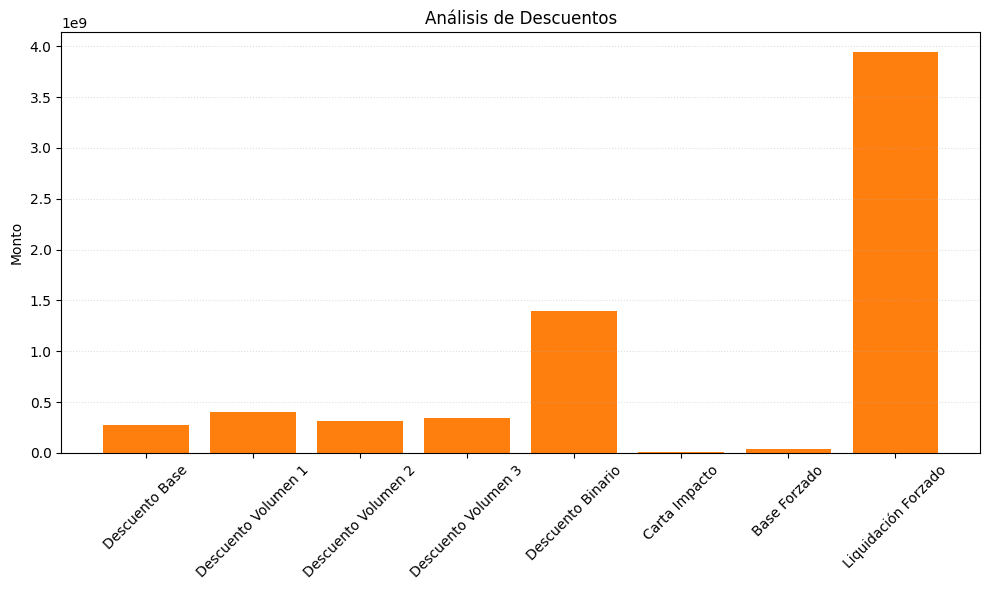

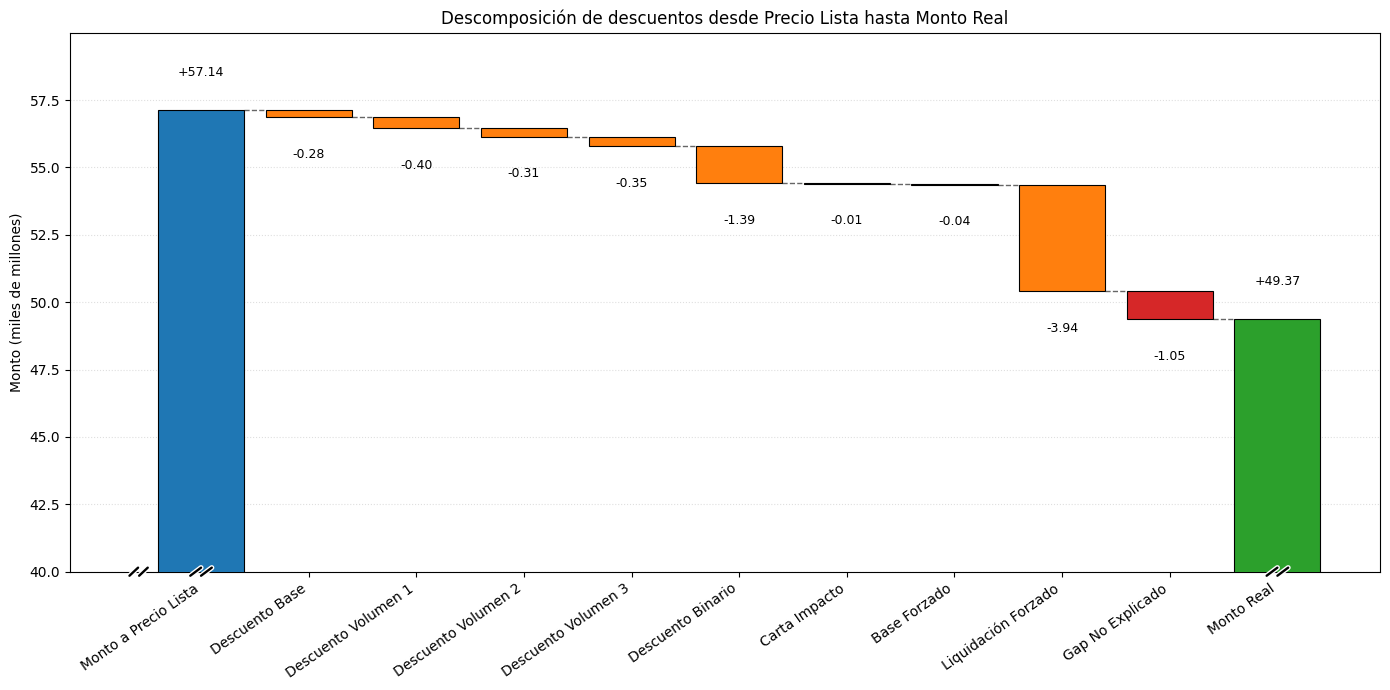

In [25]:
graficar_barras_descuentos(
    ventas,
    #incluir_precio_lista=True,
    #incluir_monto_real=True,
)

graficar_waterfall_descuentos(ventas, y_floor=40)


In [26]:
dsctos_posibles = {cat: cat for cat in ventas["descuento_aplicado"].unique()} 
dsctos_posibles["base_forzado"] = "base"

In [27]:
dsctos_posibles

{'ninguno': 'ninguno',
 'liquidacion_forzado': 'liquidacion_forzado',
 'binario': 'binario',
 'base': 'base',
 'base_forzado': 'base',
 'volumen_2': 'volumen_2',
 'volumen_1': 'volumen_1',
 'volumen_3': 'volumen_3',
 'carta_impacto': 'carta_impacto'}

<Axes: title={'center': 'Descomposición de descuentos desde Precio Lista hasta Monto Real'}, ylabel='Monto (miles de millones)'>

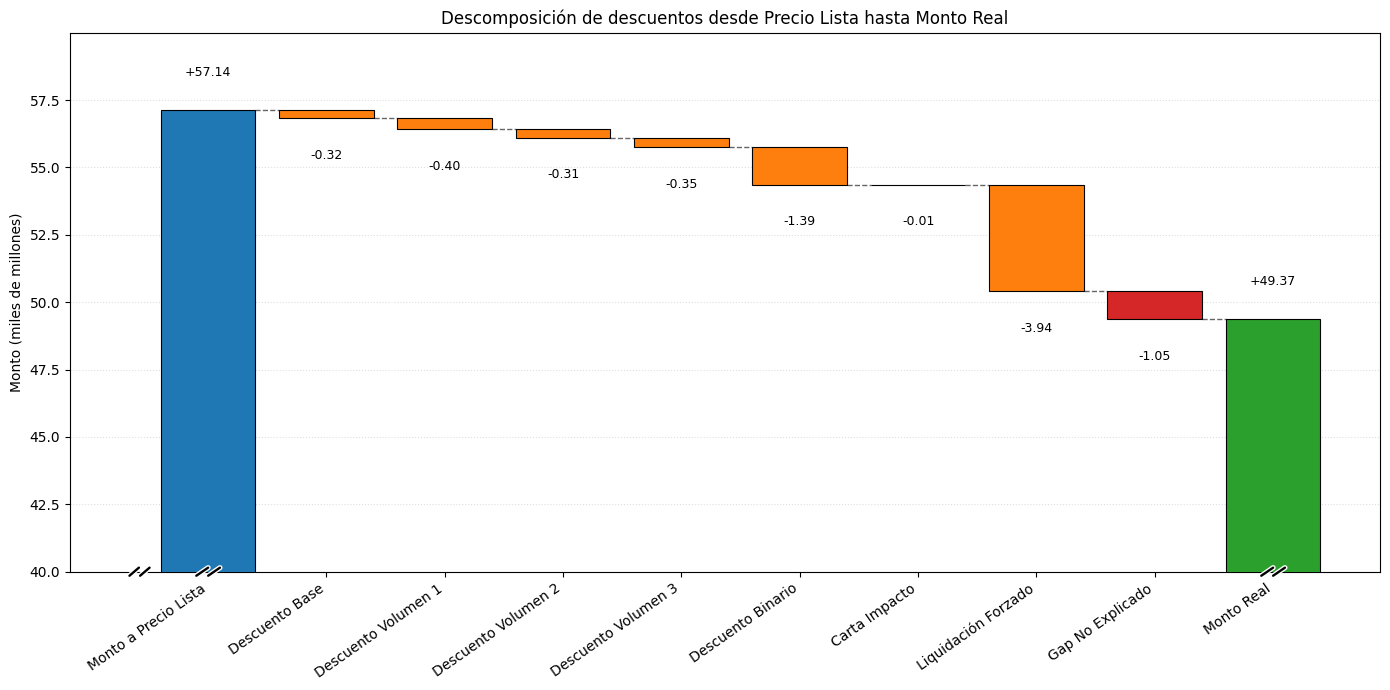

In [29]:
ventas_2 = ventas.copy()
ventas_2["descuento_aplicado"] = ventas_2["descuento_aplicado"].map(dsctos_posibles)

categorias = [
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
    "liquidacion_forzado",
]

graficar_waterfall_descuentos(ventas_2, y_floor=40, categorias=categorias)

In [30]:
ventas.columns

Index(['cod_cliente', 'cod_canal_comercial', 'cod_consolidado', 'zona',
       'distrito', 'fecha_factura', 'cod_sku', 'nombre_sku', 'monto_real',
       'kilo_real', 'precio_real', 'precio_lista', 'dscto_base',
       'dscto_volumen', 'dscto_binario', 'carta_impacto', 'id_descuento_base',
       'ids_descuento_volumen', 'id_descuento_binario',
       'id_descuento_carta_impacto', 'año_factura', 'mes_factura',
       'kg_por_unidad', 'peso_variable', 'cantidad_unidades',
       'cantidad_unidades_entera', 'inconsistencia', 'precio_por_unidad',
       'precio_lista_por_unidad', 'descuento_pct_observado',
       'descuento_pct_matcheado', 'diferencia_descuento_pct',
       'descuento_aplicado', 'id_descuento_aplicado', 'calza_con_descuento',
       'gap', 'monto_a_precio_lista', 'costo_descuento'],
      dtype='str')

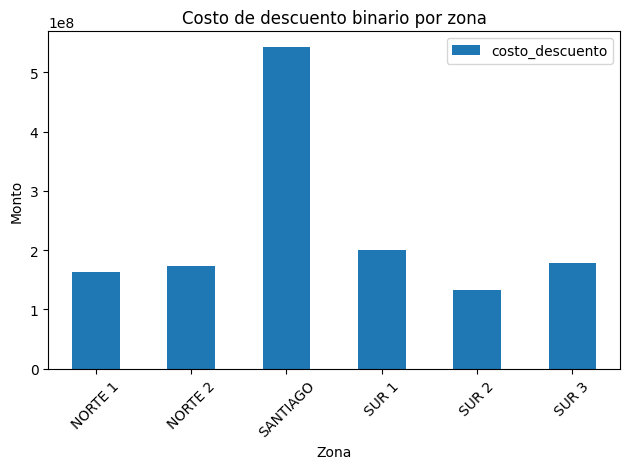

In [31]:
df_resumen = ventas[
    (ventas["descuento_aplicado"]=="binario")
].groupby(["zona"]).agg({
    # "monto_real": "sum",
    # "monto_a_precio_lista": "sum",
    "costo_descuento": "sum"
})

df_resumen.plot(kind='bar')

plt.title('Costo de descuento binario por zona')
plt.xlabel('Zona')
plt.ylabel('Monto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

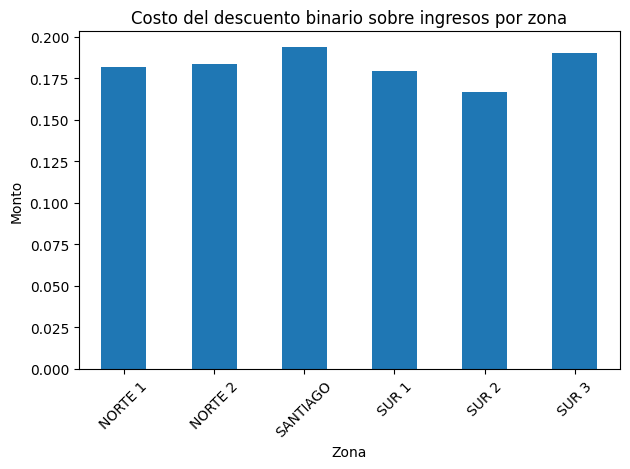

In [32]:
df_resumen = ventas[
    (ventas["descuento_aplicado"]=="binario")
].groupby(["zona"]).agg({
    "monto_real": "sum",
    "monto_a_precio_lista": "sum",
    "costo_descuento": "sum"
})

df_resumen["costo_sobre_ingresos"] = df_resumen["costo_descuento"] / df_resumen["monto_real"]

df_resumen["costo_sobre_ingresos"].plot(kind='bar')

plt.title('Costo del descuento binario sobre ingresos por zona')
plt.xlabel('Zona')
plt.ylabel('Monto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.2 Ejemplo filtrando canal


<Axes: title={'center': "Análisis de Descuentos por canal: ['CB']"}, ylabel='Monto'>

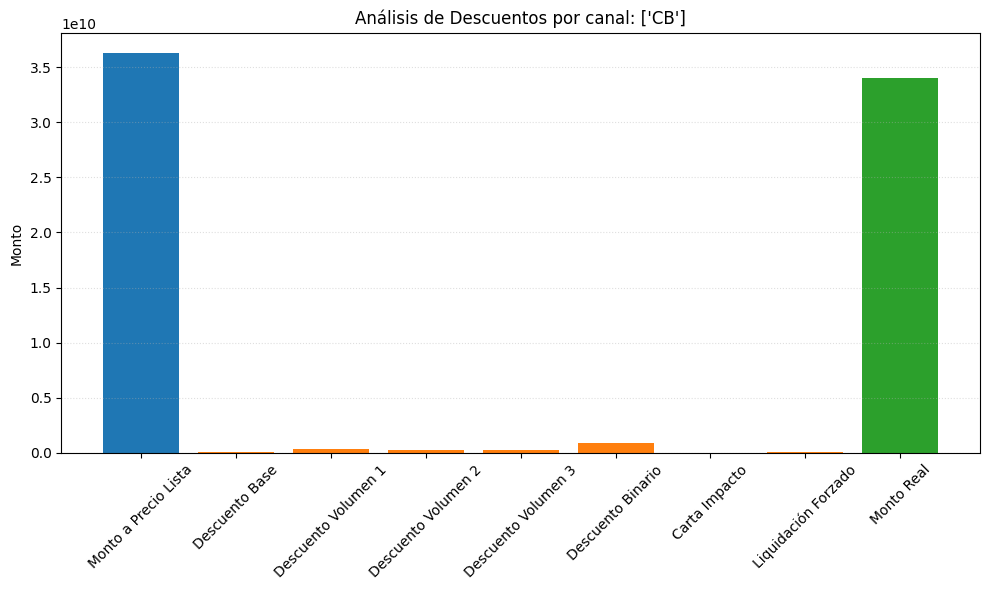

In [33]:
canal_ejemplo = (
    ventas["cod_canal_comercial"]
    .dropna()
    .value_counts()
    .head(1)
    .index
    .tolist()
)

graficar_barras_descuentos(
    ventas,
    canales=canal_ejemplo,
    unir_base_forzado=True,
    incluir_precio_lista=True,
    incluir_monto_real=True,
    titulo=f"Análisis de Descuentos por canal: {canal_ejemplo}",
)


## 3.3 Ejemplo filtrando SKU


<Axes: title={'center': 'Descomposición de descuentos para SKU: [1020]'}, ylabel='Monto (miles de millones)'>

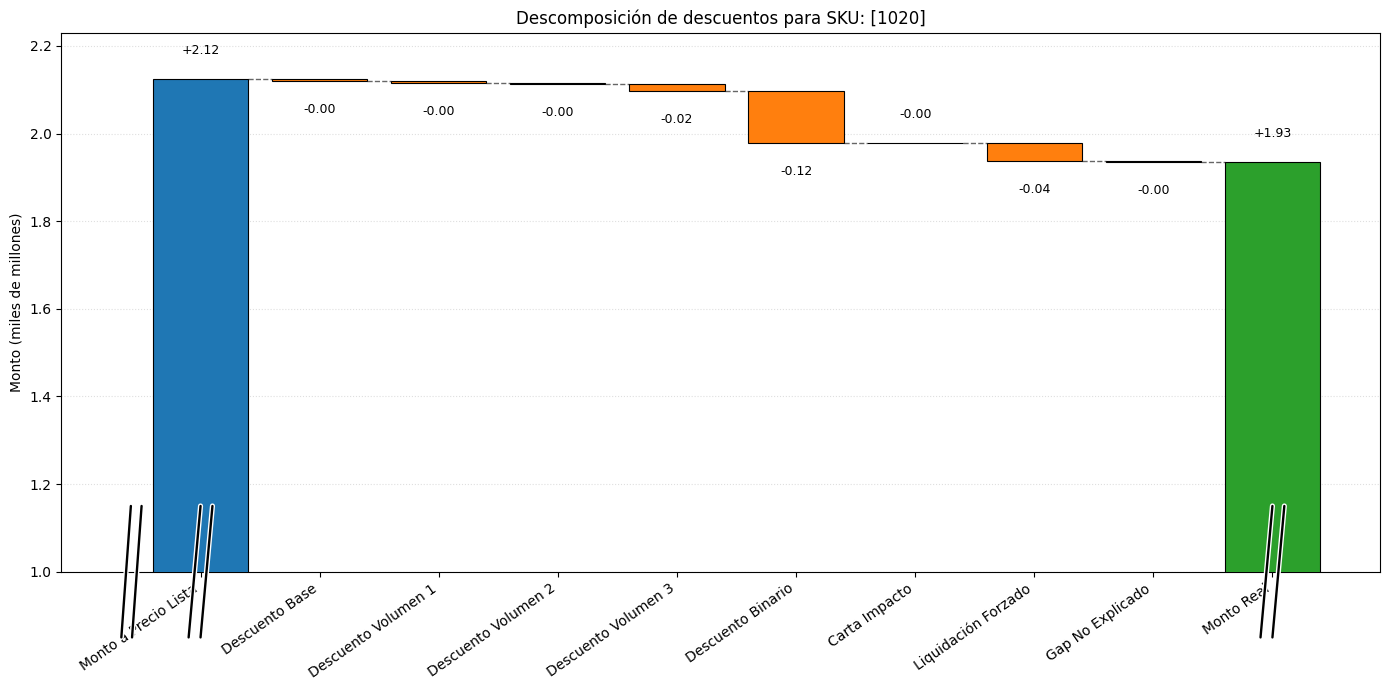

In [34]:
sku_ejemplo = ventas["cod_sku"].value_counts().head(1).index.tolist()

graficar_waterfall_descuentos(
    ventas,
    anios=[2026],
    meses=[1, 2, 3],
    skus=sku_ejemplo,
    clientes_excluir=clientes_excluir_2026_trim1,
    categorias=[
        "base",
        "volumen_1",
        "volumen_2",
        "volumen_3",
        "binario",
        "carta_impacto",
        "liquidacion_forzado",
    ],
    unir_base_forzado=True,
    y_floor=1,
    titulo=f"Descomposición de descuentos para SKU: {sku_ejemplo}",
)


# 4. Validación


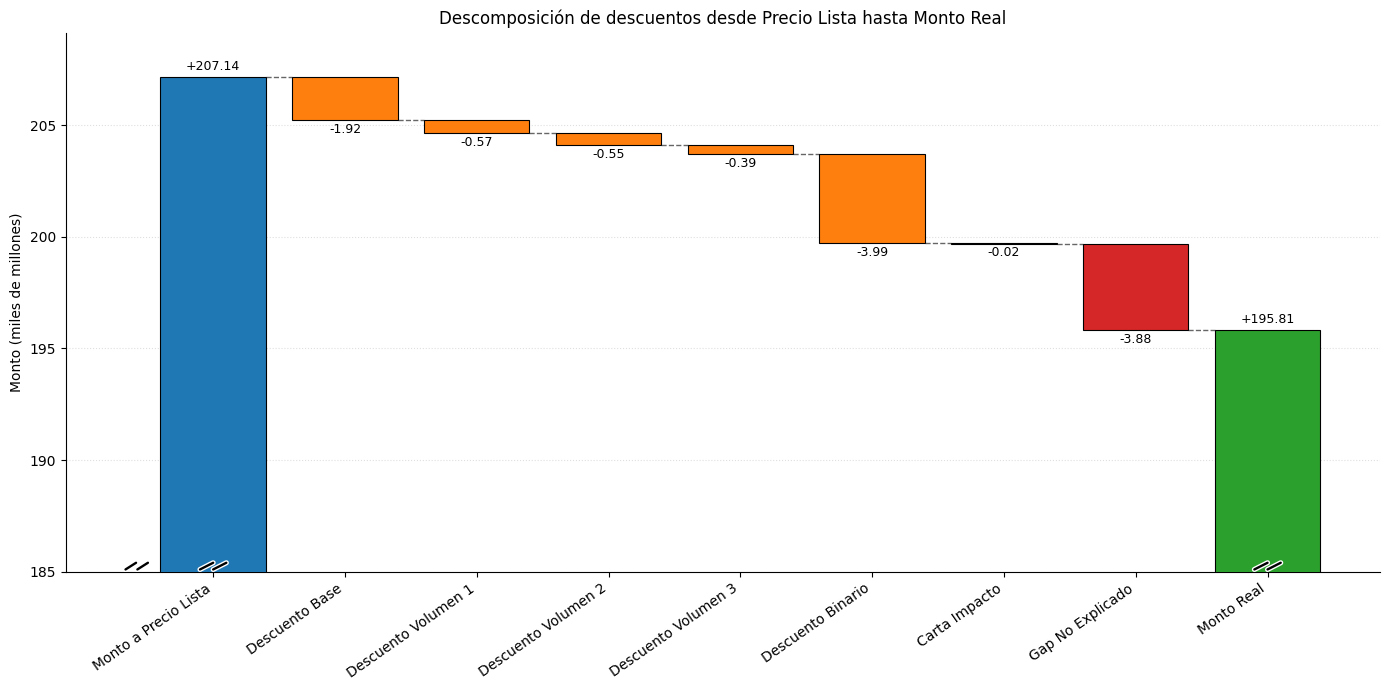

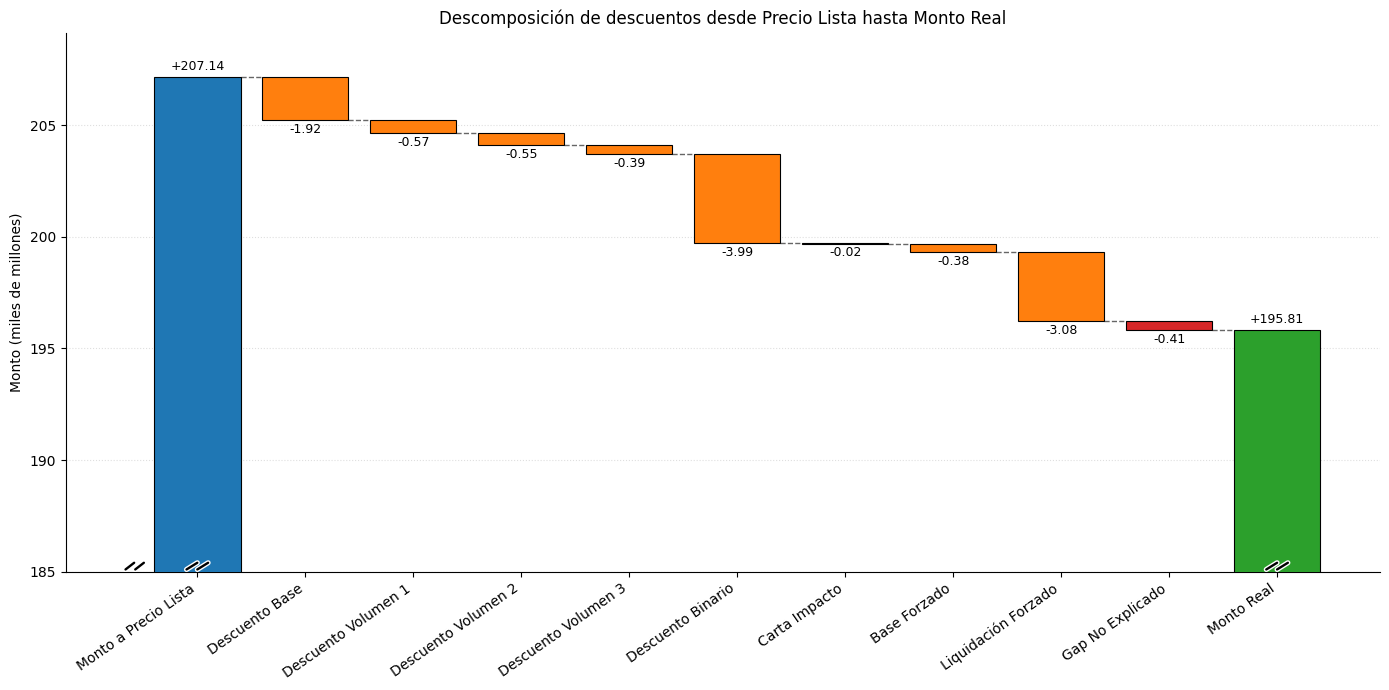


| % DSCTO OBSERVADO |         "COSTO" |
| ---------------------------------: | ------------: |
|                              -15.0 |  158 M |
|                              -10.0 |  85,9 M |
|                              -20.0 |  30,2 M |
|                              -17.0 |  25,1 M |
|                              -25.0 |  25,0 M |
|                              -18.0 |  18,7 M |
|                              -30.0 |  15,8 M |
|                              -19.0 |  10,5 M |
|                              -12.0 |  10,3 M |
|                               -9.0 |  10,2 M |
|                              -13.0 |  9,5 M |

